In [33]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import test_proportions_2indep
card = pd.read_csv("https://raw.githubusercontent.com/holleland/TECH3/main/data/bursztyn2018_experiment1.csv",
sep = ";")
card = card.dropna() # There are some missing decisions

Question 2

In [42]:


# Select ages
control_age = card.loc[card["Gold_benefits"] == 1, "age"]
treatment_age = card.loc[card["Platinum_upgrade"] == 1, "age"]

# t-test
test = stats.ttest_ind(control_age, treatment_age, alternative="two-sided")

print(test)

TtestResult(statistic=np.float64(-1.5137850444267564), pvalue=np.float64(0.1306547839848787), df=np.float64(550.0))


Question 3

In [35]:
stats.ttest_ind(control_age, treatment_age, alternative="two-sided")

TtestResult(statistic=np.float64(-1.5137850444267564), pvalue=np.float64(0.1306547839848787), df=np.float64(550.0))

Question 4

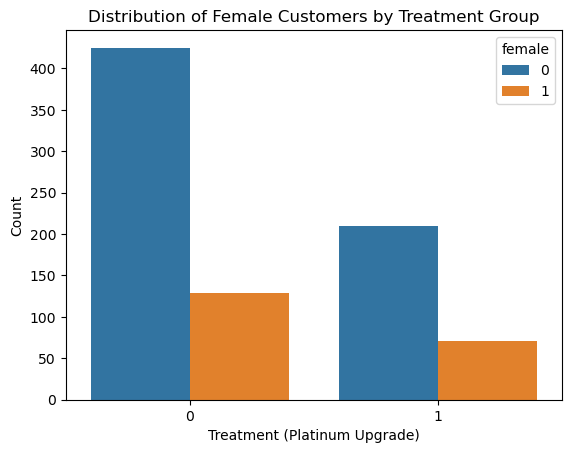

statistic = 0.2507256026768035
pvalue = 0.8020262647342524
compare = diff
method = agresti-caffo
diff = 0.009323580780291774
ratio = 1.03690036900369
odds_ratio = 1.0499999999999998
variance = 0.0013815590749122455
alternative = two-sided
value = 0
tuple = (np.float64(0.2507256026768035), np.float64(0.8020262647342524))


In [37]:
sns.countplot(data=card, x="Platinum_upgrade", hue="female")

plt.xlabel("Treatment (Platinum Upgrade)")
plt.ylabel("Count")
plt.title("Distribution of Female Customers by Treatment Group")

plt.show()
female_control = card.loc[card["Gold_benefits"] == 1, "female"].sum()
female_treatment = card.loc[card["Platinum_upgrade"] == 1, "female"].sum()

n_control = len(card.loc[card["Gold_benefits"] == 1])
n_treatment = len(card.loc[card["Platinum_upgrade"] == 1])

test = test_proportions_2indep(
    count1=female_control,
    nobs1=n_control,
    count2=female_treatment,
    nobs2=n_treatment,
    alternative="two-sided"
)

print(test)

Quesstion 5

statistic = -2.2698350967190306
pvalue = 0.02321759024486838
compare = diff
method = agresti-caffo
diff = -0.07343304749773474
ratio = 0.6502595534429921
odds_ratio = 0.5949587136027815
variance = 0.0010292305692636101
alternative = two-sided
value = 0
tuple = (np.float64(-2.2698350967190306), np.float64(0.02321759024486838))


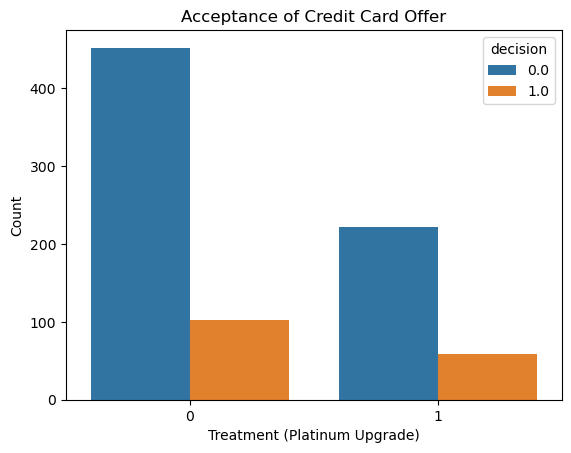

In [38]:
# Accepted offers
accept_control = card.loc[card["Gold_benefits"] == 1, "decision"].sum()
accept_treatment = card.loc[card["Platinum_upgrade"] == 1, "decision"].sum()

# Total observations
n_control = len(card.loc[card["Gold_benefits"] == 1])
n_treatment = len(card.loc[card["Platinum_upgrade"] == 1])

# Test of proportions
test_accept = test_proportions_2indep(
    count1=accept_control,
    nobs1=n_control,
    count2=accept_treatment,
    nobs2=n_treatment,
    alternative="two-sided"
)

print(test_accept)

sns.countplot(data=card, x="Platinum_upgrade", hue="decision")

plt.xlabel("Treatment (Platinum Upgrade)")
plt.ylabel("Count")
plt.title("Acceptance of Credit Card Offer")

plt.show()

Question 7

In [40]:
import numpy as np
# Create two groups of 100 observations each
# 1 = "yes", 0 = "no"
group_A = np.array([1] * 21 + [0] * 79)
group_B = np.array([1] * 14 + [0] * 86)

# Combine the data into one array
data = np.concatenate([group_A, group_B])

# Create labels showing which observation belongs to which group
labels = np.array(["A"] * len(group_A) + ["B"] * len(group_B))

# Function to compute the difference in proportions
def prop_diff(labels, data):
    group_A_data = data[labels == "A"]
    group_B_data = data[labels == "B"]
    return group_A_data.mean() - group_B_data.mean()

# Observed difference in proportions
obs_diff = prop_diff(labels, data)

# Number of permutations
n_permutations = 10000

# Store simulated differences
diffs = []

# Shuffle labels many times
for _ in range(n_permutations):
    shuffled_labels = np.random.permutation(labels)
    diffs.append(prop_diff(shuffled_labels, data))

# Convert to numpy array
diffs = np.array(diffs)

# Two-sided p-value
p_value = np.mean(np.abs(diffs) >= np.abs(obs_diff))

# Print results
print("Observed difference:", obs_diff)
print("P-value:", p_value)

Observed difference: 0.06999999999999998
P-value: 0.2691


Quetsion 8

In [41]:
# Keep only control and treatment 1
subset = card[(card["Gold_benefits"] == 1) | (card["Platinum_upgrade"] == 1)].copy()

subset["group"] = np.where(subset["Gold_benefits"] == 1, "Control", "Treatment")

data = subset["decision"].to_numpy()
labels = subset["group"].to_numpy()

def prop_diff(labels, data):
    return data[labels == "Treatment"].mean() - data[labels == "Control"].mean()

obs_diff = prop_diff(labels, data)

n_permutations = 10000
diffs = []

for _ in range(n_permutations):
    shuffled_labels = np.random.permutation(labels)
    diffs.append(prop_diff(shuffled_labels, data))

diffs = np.array(diffs)

p_value = np.mean(np.abs(diffs) >= np.abs(obs_diff))

print("Observed difference:", obs_diff)
print("Permutation p-value:", p_value)

Observed difference: 0.07343304749773474
Permutation p-value: 0.027
